# Normal-Normal Conjugacy: Precision, Inverse-Variance Weighting & The Bayesian Tug-of-War
### *A Deep-Dive First-Principles Derivation of Bayesian Updating for Gaussian Models*

---

## 🎯 Conceptual Overview: The "Tug-of-War"

When you update your beliefs using Bayes' Rule, the resulting **Posterior Distribution** represents an optimal mathematical compromise between two competing sources of information:
1. **Your Prior State of Knowledge**: What you believed before collecting data ($p(\mu)$).
2. **Your Observed Evidence / Likelihood**: What your sensors, instruments, or measurements report ($p(y \mid \mu)$).

A natural and fundamental question arises:
> **How does Bayes' Rule decide who gets more say in the compromise?**
> Does the posterior side with the prior, or does it side with the data?

Under a Gaussian (Normal) model, the answer is remarkably elegant:
$$\textbf{Influence is inversely proportional to noise (variance).}$$

The source with **smaller noise (higher certainty)** gets the lion's share of the vote, while the source with **larger noise** is largely discounted.

---

## Part 1: Anatomy of the Weighting Formulas

Let us formalize the vocabulary:
* $\mu_0, \sigma_0$: Prior mean and prior standard deviation (variance $\sigma_0^2$).
* $y, \sigma$: Observed data measurement and instrument noise standard deviation (variance $\sigma^2$).

### 1.1 What are $w_0$ and $w_L$?
The letter **$w$ stands for "weight"** (influence):
* **$w_0 = \frac{1}{\sigma_0^2}$**: The weight of the **Prior** (subscript $0$ denotes the initial baseline).
* **$w_L = \frac{1}{\sigma^2}$**: The weight of the **Likelihood / Data** ($L$ stands for Likelihood).

*(In classical statistics literature, inverse variance $\tau = \frac{1}{\sigma^2}$ is called **precision**. Modern software like PyMC and Stan prefers standard deviation $\sigma$, but the concept is identical: smaller error $\implies$ larger weight).*

### 1.2 What is the $W_{\text{data}}$ Formula?
Just like computing your course grade from Homework ($30\%$) and an Exam ($70\%$):
$$\text{Exam Share} = \frac{\text{Exam Weight}}{\text{Total Weight}}$$

In Bayesian updating, the **total weight** is $w_0 + w_L$. The percentage share of the vote awarded to each source is:
$$W_{\text{data}} = \frac{w_L}{w_0 + w_L} = \frac{\text{Data Weight}}{\text{Total Weight}}$$
$$W_{\text{prior}} = \frac{w_0}{w_0 + w_L} = \frac{\text{Prior Weight}}{\text{Total Weight}}$$

### 1.3 The Posterior Mean Formula: $\mu_{\text{post}}$
The posterior mean is the **weighted average** of the prior mean and the data:
$$\mu_{\text{post}} = \frac{w_0 \mu_0 + w_L y}{w_0 + w_L} = W_{\text{prior}} \cdot \mu_0 + W_{\text{data}} \cdot y$$

And the **posterior variance** $\sigma_{\text{post}}^2$ is simply the inverse of the total weight:
$$\sigma_{\text{post}}^2 = \frac{1}{w_0 + w_L} = \frac{1}{\frac{1}{\sigma_0^2} + \frac{1}{\sigma^2}}$$
*(Notice that because $w_0 + w_L > w_0$ and $w_0 + w_L > w_L$, the posterior variance is **always smaller** than both the prior and data variances! Every piece of data reduces uncertainty).*


---

## Part 2: First-Principles Derivation (Completing the Square)

Why does multiplying two bell curves produce this exact weighted average formula?  
Let us derive it step-by-step from **Bayes' Theorem**:

$$p(\mu \mid y) \propto p(\mu) \times p(y \mid \mu)$$

### Step A: Write the Probability Density Functions
A standard Normal curve centered at mean $m$ with variance $v$ has density:
$$p(x) = \frac{1}{\sqrt{2\pi v}} \exp\left( -\frac{(x - m)^2}{2v} \right) \propto \exp\left( -\frac{1}{2} \cdot \frac{1}{v} \cdot (x - m)^2 \right)$$

Substitute our weights $w_0 = \frac{1}{\sigma_0^2}$ and $w_L = \frac{1}{\sigma^2}$:
* **Prior**: $p(\mu) \propto \exp\left( -\frac{1}{2} w_0 (\mu - \mu_0)^2 \right)$
* **Likelihood**: $p(y \mid \mu) \propto \exp\left( -\frac{1}{2} w_L (y - \mu)^2 \right) = \exp\left( -\frac{1}{2} w_L (\mu - y)^2 \right)$

### Step B: Multiply Them (Add the Exponents)
When multiplying exponential functions, their powers add:
$$\text{Exponent} = -\frac{1}{2} \Big[ w_0 (\mu - \mu_0)^2 + w_L (\mu - y)^2 \Big]$$

### Step C: Expand the Quadratic Brackets
$$\begin{aligned}
w_0 (\mu - \mu_0)^2 + w_L (\mu - y)^2 &= w_0 (\mu^2 - 2\mu_0\mu + \mu_0^2) + w_L (\mu^2 - 2y\mu + y^2) \\
&= \mathbf{(w_0 + w_L)}\mu^2 - 2\mathbf{(w_0\mu_0 + w_L y)}\mu + (w_0\mu_0^2 + w_L y^2)
\end{aligned}$$
*(The trailing term $w_0\mu_0^2 + w_L y^2$ does not depend on $\mu$, so it is simply absorbed into the normalizing constant).*

### Step D: Complete the Square
Any Gaussian density centered at an unknown mode $\mu_{\text{post}}$ with precision $C$ matches the template:
$$-\frac{1}{2} C (\mu - \mu_{\text{post}})^2 = -\frac{1}{2} \Big[ C\mu^2 - 2(C \cdot \mu_{\text{post}})\mu + C\mu_{\text{post}}^2 \Big]$$

Matching coefficients between Step C and Step D:
1. **Coefficient of $\mu^2$**:
   $$C = \mathbf{w_0 + w_L} = \frac{1}{\sigma_0^2} + \frac{1}{\sigma^2}$$
   Therefore, the posterior variance is:
   $$\sigma_{\text{post}}^2 = \frac{1}{C} = \mathbf{\frac{1}{w_0 + w_L}}$$

2. **Coefficient of $-2\mu$**:
   $$C \cdot \mu_{\text{post}} = w_0\mu_0 + w_L y$$
   Dividing through by $C$:
   $$\mu_{\text{post}} = \frac{w_0\mu_0 + w_L y}{C} = \mathbf{\frac{w_0 \mu_0 + w_L y}{w_0 + w_L}} \quad \blacksquare$$


=== Analytical Updating Calculations ===
Scenario 1: Equal Noise (50/50 Compromise):
   w_0: 0.0400 (50.0%) | w_L: 0.0400 (50.0%)
   Posterior: N(mu=182.50, sigma=3.54)

Scenario 2: Precise Sensor (Data Wins):
   w_0: 0.0400 (3.8%) | w_L: 1.0000 (96.2%)
   Posterior: N(mu=194.04, sigma=0.98)

Scenario 3: Strong Prior (Prior Wins):
   w_0: 1.0000 (96.2%) | w_L: 0.0400 (3.8%)
   Posterior: N(mu=170.96, sigma=0.98)



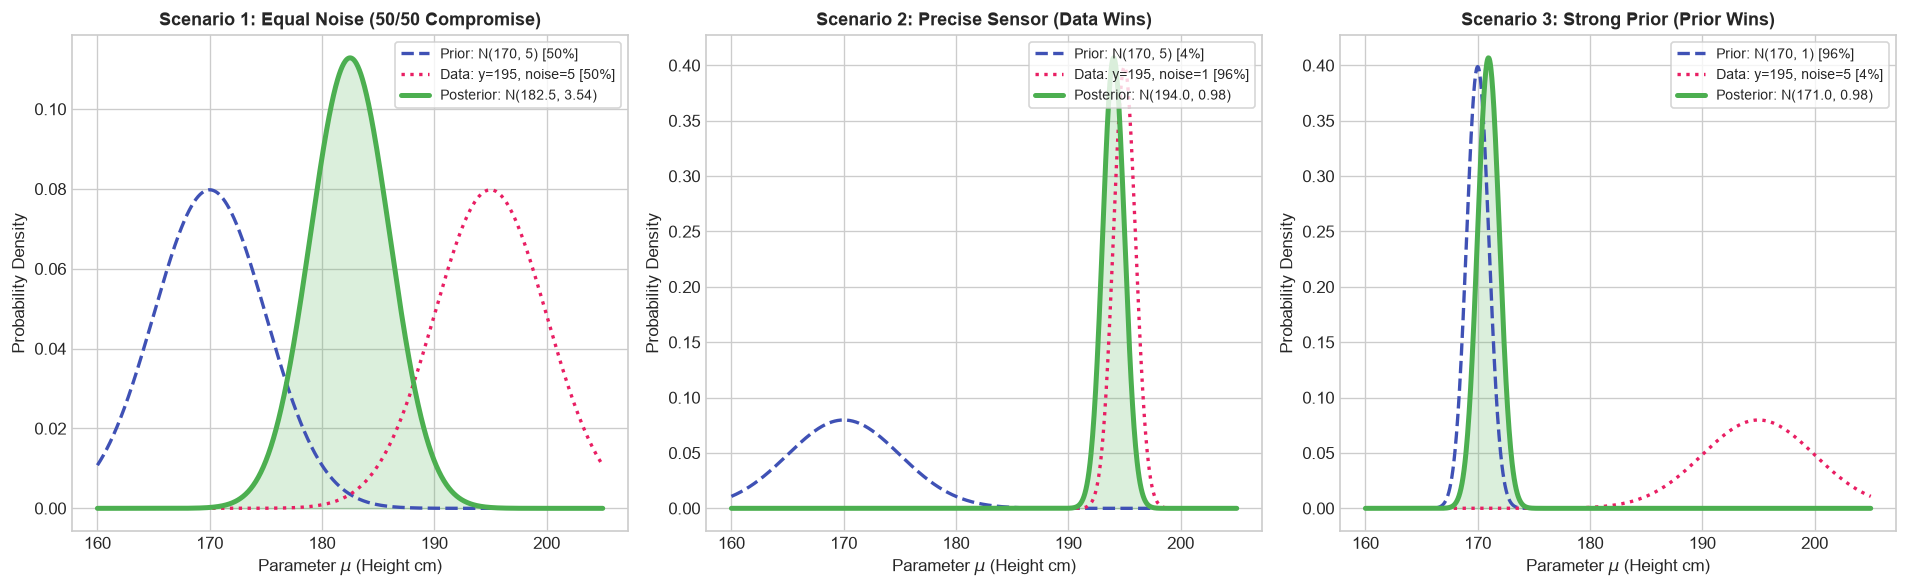

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Set styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=120)

# Common evaluation grid
x = np.linspace(160, 205, 1000)

scenarios = [
    {
        "title": "Scenario 1: Equal Noise (50/50 Compromise)",
        "mu_0": 170.0, "sigma_0": 5.0,
        "y": 195.0, "sigma": 5.0,
        "ax": axes[0]
    },
    {
        "title": "Scenario 2: Precise Sensor (Data Wins)",
        "mu_0": 170.0, "sigma_0": 5.0,
        "y": 195.0, "sigma": 1.0,
        "ax": axes[1]
    },
    {
        "title": "Scenario 3: Strong Prior (Prior Wins)",
        "mu_0": 170.0, "sigma_0": 1.0,
        "y": 195.0, "sigma": 5.0,
        "ax": axes[2]
    }
]

print("=== Analytical Updating Calculations ===")
for sc in scenarios:
    mu_0, s_0 = sc["mu_0"], sc["sigma_0"]
    y, s = sc["y"], sc["sigma"]
    
    # 1. Weights
    w_0 = 1.0 / (s_0**2)
    w_L = 1.0 / (s**2)
    
    # 2. Percentage shares
    W_prior = (w_0 / (w_0 + w_L)) * 100
    W_data  = (w_L / (w_0 + w_L)) * 100
    
    # 3. Posterior parameters
    mu_post = (w_0 * mu_0 + w_L * y) / (w_0 + w_L)
    sigma_post = np.sqrt(1.0 / (w_0 + w_L))
    
    print(f"{sc['title']}:")
    print(f"   w_0: {w_0:.4f} ({W_prior:.1f}%) | w_L: {w_L:.4f} ({W_data:.1f}%)")
    print(f"   Posterior: N(mu={mu_post:.2f}, sigma={sigma_post:.2f})\n")
    
    # Plotting
    ax = sc["ax"]
    p_prior = norm.pdf(x, mu_0, s_0)
    p_lik = norm.pdf(x, y, s)
    p_post = norm.pdf(x, mu_post, sigma_post)
    
    ax.plot(x, p_prior, label=f"Prior: N({mu_0:.0f}, {s_0:.0f}) [{W_prior:.0f}%]", color='#3F51B5', lw=2, linestyle='--')
    ax.plot(x, p_lik, label=f"Data: y={y:.0f}, noise={s:.0f} [{W_data:.0f}%]", color='#E91E63', lw=2, linestyle=':')
    ax.plot(x, p_post, label=f"Posterior: N({mu_post:.1f}, {sigma_post:.2f})", color='#4CAF50', lw=3)
    ax.fill_between(x, p_post, color='#4CAF50', alpha=0.2)
    
    ax.set_title(sc["title"], fontsize=11, fontweight='bold')
    ax.set_xlabel("Parameter $\\mu$ (Height cm)", fontsize=10)
    ax.set_ylabel("Probability Density", fontsize=10)
    ax.legend(loc='upper right', fontsize=8.5, frameon=True)

plt.tight_layout()
plt.show()


---

## Part 3: Scaling to $N$ Observations ($n \to \infty$)

What happens when we observe not just a single person $y$, but a sample of $n$ observations $y_1, y_2, \dots, y_n$ with sample average $\bar{y} = \frac{1}{n} \sum y_i$?

Under independent Normal sampling with fixed noise $\sigma$, the joint likelihood exponent sums over all $n$ data points:
$$\sum_{i=1}^n -\frac{(y_i - \mu)^2}{2\sigma^2} = -\frac{1}{2} \left( \frac{n}{\sigma^2} \right) (\mu - \bar{y})^2 + \text{const}$$

Notice the data weight is multiplied by $n$:
* **Prior Weight**: $w_0 = \frac{1}{\sigma_0^2}$
* **Collective Data Weight**: $w_L = \mathbf{\frac{n}{\sigma^2}}$

The updating formula becomes:
$$\mu_{\text{post}} = \frac{\frac{1}{\sigma_0^2}\mu_0 + \frac{n}{\sigma^2}\bar{y}}{\frac{1}{\sigma_0^2} + \frac{n}{\sigma^2}}$$

$$\sigma_{\text{post}}^2 = \frac{1}{\frac{1}{\sigma_0^2} + \frac{n}{\sigma^2}}$$

### The Inevitable Triumph of Evidence (Bernstein-von Mises Theorem)
* Notice that as $n \to \infty$, the data weight $\frac{n}{\sigma^2}$ grows without bound, while the prior weight $\frac{1}{\sigma_0^2}$ remains constant.
* As $n$ increases:
  $$\lim_{n \to \infty} W_{\text{data}} = \lim_{n \to \infty} \frac{\frac{n}{\sigma^2}}{\frac{1}{\sigma_0^2} + \frac{n}{\sigma^2}} = \mathbf{100\%}$$
  $$\lim_{n \to \infty} \mu_{\text{post}} = \mathbf{\bar{y}}$$
* This is why in production with large datasets (e.g. $n = 10,000$), your choice of reasonable prior has virtually zero influence on the final posterior mean!


---

## 🎯 Hands-On Challenge: Autonomous Vehicle Sensor Fusion

> **Scenario**: An autonomous vehicle estimates its distance to an obstacle ahead.
> * **Prior Belief (GPS & Inertial Odometry)**: Distance $\mu_0 = 50.0\text{ m}$ with uncertainty $\sigma_0 = 4.0\text{ m}$.
> * **Sensor Reading 1 (Ultrasonic Sonar)**: Noisy reading $y_1 = 44.0\text{ m}$ with error $\sigma_1 = 3.0\text{ m}$.
> * **Sensor Reading 2 (LIDAR)**: Hyper-precise reading $y_2 = 42.0\text{ m}$ with error $\sigma_2 = 0.5\text{ m}$.
> 
> Compute the updated distance estimate after incorporating:
> 1. Only the Sonar reading.
> 2. Both the Sonar AND the LIDAR reading.


In [2]:
# Sensor Fusion Exercise
mu_0, sigma_0 = 50.0, 4.0
y_sonar, sigma_sonar = 44.0, 3.0
y_lidar, sigma_lidar = 42.0, 0.5

# Step 1: Incorporate Sonar
w_0 = 1.0 / (sigma_0**2)
w_sonar = 1.0 / (sigma_sonar**2)
mu_after_sonar = (w_0 * mu_0 + w_sonar * y_sonar) / (w_0 + w_sonar)
sigma_after_sonar = np.sqrt(1.0 / (w_0 + w_sonar))

# Step 2: Incorporate LIDAR (using previous posterior as the new prior)
w_prev = 1.0 / (sigma_after_sonar**2)
w_lidar = 1.0 / (sigma_lidar**2)
mu_final = (w_prev * mu_after_sonar + w_lidar * y_lidar) / (w_prev + w_lidar)
sigma_final = np.sqrt(1.0 / (w_prev + w_lidar))

print(f"Prior:          {mu_0:.2f} m (+/- {sigma_0:.2f} m)")
print(f"After Sonar:    {mu_after_sonar:.2f} m (+/- {sigma_after_sonar:.2f} m)")
print(f"After LIDAR:    {mu_final:.2f} m (+/- {sigma_final:.2f} m)")
print(f"LIDAR Voting Share: {(w_lidar / (w_prev + w_lidar))*100:.1f}%")


Prior:          50.00 m (+/- 4.00 m)
After Sonar:    46.16 m (+/- 2.40 m)
After LIDAR:    42.17 m (+/- 0.49 m)
LIDAR Voting Share: 95.8%
